In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# 시드 설정
np.random.seed(42)

print("-" * 60)
print("라이브러리 로드 완료")
print("한글 폰트 설정 완료!")
print("-" * 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath(".."))
print(os.getcwd())

df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv").drop(columns="Unnamed: 0")
df.head()

d:\Dev\airbnb_price_prediction


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,f,Prospect Heights,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,90,365,90.0,90.0,365.0,365.0,90.0,365.0,NaN,t,27,57,87,362,2025-03-03,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,100%,f,East Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,30,999,30.0,30.0,999.0,999.0,30.0,999.0,NaN,t,0,0,0,204,2025-03-03,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,100%,40%,f,Boerum Hill,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,3,60,3.0,3.0,60.0,60.0,3.0,60.0,NaN,t,30,49,66,326,2025-03-02,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,100%,97%,t,Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,7,18,25,25,2025-03-03,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,

In [3]:
df_cleaned = pd.read_csv("data/df_cleaned.csv")

In [4]:
df_cleaned.shape

(22308, 73)

In [5]:
df_reviews = pd.read_csv("data/df_reviews_cleaned.csv")

## 단변량 분석 총정리 (리뷰/평점 컬럼 기준)

### 결측치 처리 (완료)
- 'number_of_reviews'가 0(리뷰 없음)인 경우, 다른 리뷰 관련 컬럼에 같은 수의 결측치 발생 확인, 월별 리뷰 수 ('reviews_per_month') 및 평점 관련 컬럼('review_scores_~') 결측치를 모두 0(리뷰 없음)으로 바꿈.
> 리뷰없음의 의미가 뭐지? 리뷰가 없으면, 경력이 없는 신규 호스트의 숙소고 리뷰가 있으면 경력이 있는 호스트의 숙소일까?
> host_since랑 다변량 분석

### 타입 및 통계 지표
- 타입 확인: 리뷰 개수는 정수형(int), 월별 리뷰수 및 평점 데이터는 연속형(float)
- 지표 확인

### 통계 지표 왜곡 가능성 발견 대박
- 0(리뷰 없음)의 비율이 전체의 30%이상 차지함: 전체 기준 평균 리뷰 개수(34개), 중앙값(5개) 및 평균 평점(약 3.28점)은 에어비앤비 데이터를 대표하지 못함. 실제 시장의 평가를 왜곡시키는 결과.
- 어떻게 해야 할까? 
  1. 평균 보다는 최빈값(Mode) 참고?
  2. 분석 목표인 숙소의 적정 가격('price') 예측 모델을 만들 때, '리뷰가 있는 숙소'와 '신규/미평가 숙소' 로 분리 분석 
> 파생 변수('has_review' = True/False)

In [6]:
# 데이터 타입, 결측치
df_reviews.info()

# 통계량 확인
display(df_reviews.describe().round(2))

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   number_of_reviews            22308 non-null  int64  
 1   reviews_per_month            22308 non-null  float64
 2   number_of_reviews_ltm        22308 non-null  int64  
 3   number_of_reviews_l30d       22308 non-null  int64  
 4   number_of_reviews_ly         22308 non-null  int64  
 5   first_review                 22308 non-null  str    
 6   last_review                  22308 non-null  str    
 7   review_scores_rating         22308 non-null  float64
 8   review_scores_accuracy       22308 non-null  float64
 9   review_scores_cleanliness    22308 non-null  float64
 10  review_scores_checkin        22308 non-null  float64
 11  review_scores_communication  22308 non-null  float64
 12  review_scores_location       22308 non-null  float64
 13  review_scores_value        

,number_of_reviews,reviews_per_month,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00
mean,34.35,0.81,6.14,0.32,5.91,3.28,3.30,3.26,3.36,3.35,3.29,3.21
std,76.78,1.93,24.60,1.88,24.12,2.21,2.22,2.19,2.25,2.24,2.20,2.16
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5.00,0.21,0.00,0.00,0.00,4.69,4.74,4.64,4.83,4.83,4.67,4.56
75%,35.00,0.94,3.00,0.00,3.00,4.92,4.94,4.91,4.99,5.00,4.91,4.82
max,2749.00,117.98,1784.00,135.00,1797.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [7]:
# 0(리뷰 없음) 숙소와 0이 아닌(리뷰 있음) 숙소 분리
df_with_reviews = df_reviews[df_reviews["number_of_reviews"] > 0]
df_no_reviews = df_reviews[df_reviews["number_of_reviews"] == 0]

# 리뷰 있는 숙소 비율
total_count = len(df_reviews)
no_review_count = len(df_no_reviews)
ratio = (no_review_count / total_count) * 100

print(f"전체 숙소 중 리뷰가 없는(0) 숙소의 비율: {ratio:.2f}%\n")

전체 숙소 중 리뷰가 없는(0) 숙소의 비율: 30.47%



#### 리뷰 통계 왜곡 정정 (미평가 숙소 제외, 리뷰 있음만 분리해서 통계량 구함)
- 평균이 49.41 인데, 중앙값은 18 -> 초대박난 숙소들이 평균을 끌어올리고 있음

#### 평점 통계 왜곡 정정 (미평가 숙소 제외, 리뷰 있음만 분리해서 통계량 구함)
- 뉴욕 에어비앤비 숙소 평점의 하위 25%가 4.66으로 전체적으로 평점이 상향 평준화 되어있음을 확인
- 4.5 이하일 경우 만족도가 낮음으로 해석할 수 있음

In [8]:
# 리뷰 있는 숙소 일때 리뷰, 평점 통계량
display(df_with_reviews.describe().round(2))

,number_of_reviews,reviews_per_month,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00
mean,49.41,1.16,8.83,0.46,8.51,4.72,4.75,4.69,4.83,4.81,4.73,4.61
std,87.95,2.22,29.10,2.24,28.54,0.46,0.44,0.47,0.37,0.42,0.39,0.50
min,1.00,0.01,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00
25%,4.00,0.18,0.00,0.00,0.00,4.66,4.70,4.60,4.81,4.80,4.64,4.51
50%,18.00,0.50,1.00,0.00,1.00,4.85,4.88,4.83,4.94,4.94,4.82,4.75
75%,58.00,1.49,4.00,0.00,4.00,5.00,5.00,4.98,5.00,5.00,5.00,4.89
max,2749.00,117.98,1784.00,135.00,1797.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


# 리뷰/평점 관련 컬럼들 분포 확인 (리뷰가 있는 숙소만)

In [9]:
# 리뷰 / 평점 그룹 나눠 (단위가 다름 이슈)
# 리뷰 개수 관련
count_cols = ["number_of_reviews", "reviews_per_month", "number_of_reviews_ltm", "number_of_reviews_l30d"]

# 평점 관련 (0제외, ~5점)
score_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]

#### 분포 특징
- 리뷰 개수 분포: 대부분의 숙소가 0 ~ 몇십개, 소수의 숙소가 몇백개 이상인 '긴꼬리 분포'.
- 평점 분포: 0점을 제외하면, 대부분의 평점이 4.0점 ~ 5.0점 사이에 집중. -> '없는 그룹(0점)'과 '매우 높은 그룹(4.5~5.0점)'으로 나뉘어 있음. -> 극단적

# 리뷰/평점 관련 컬럼들 이상치 분포 살펴보기

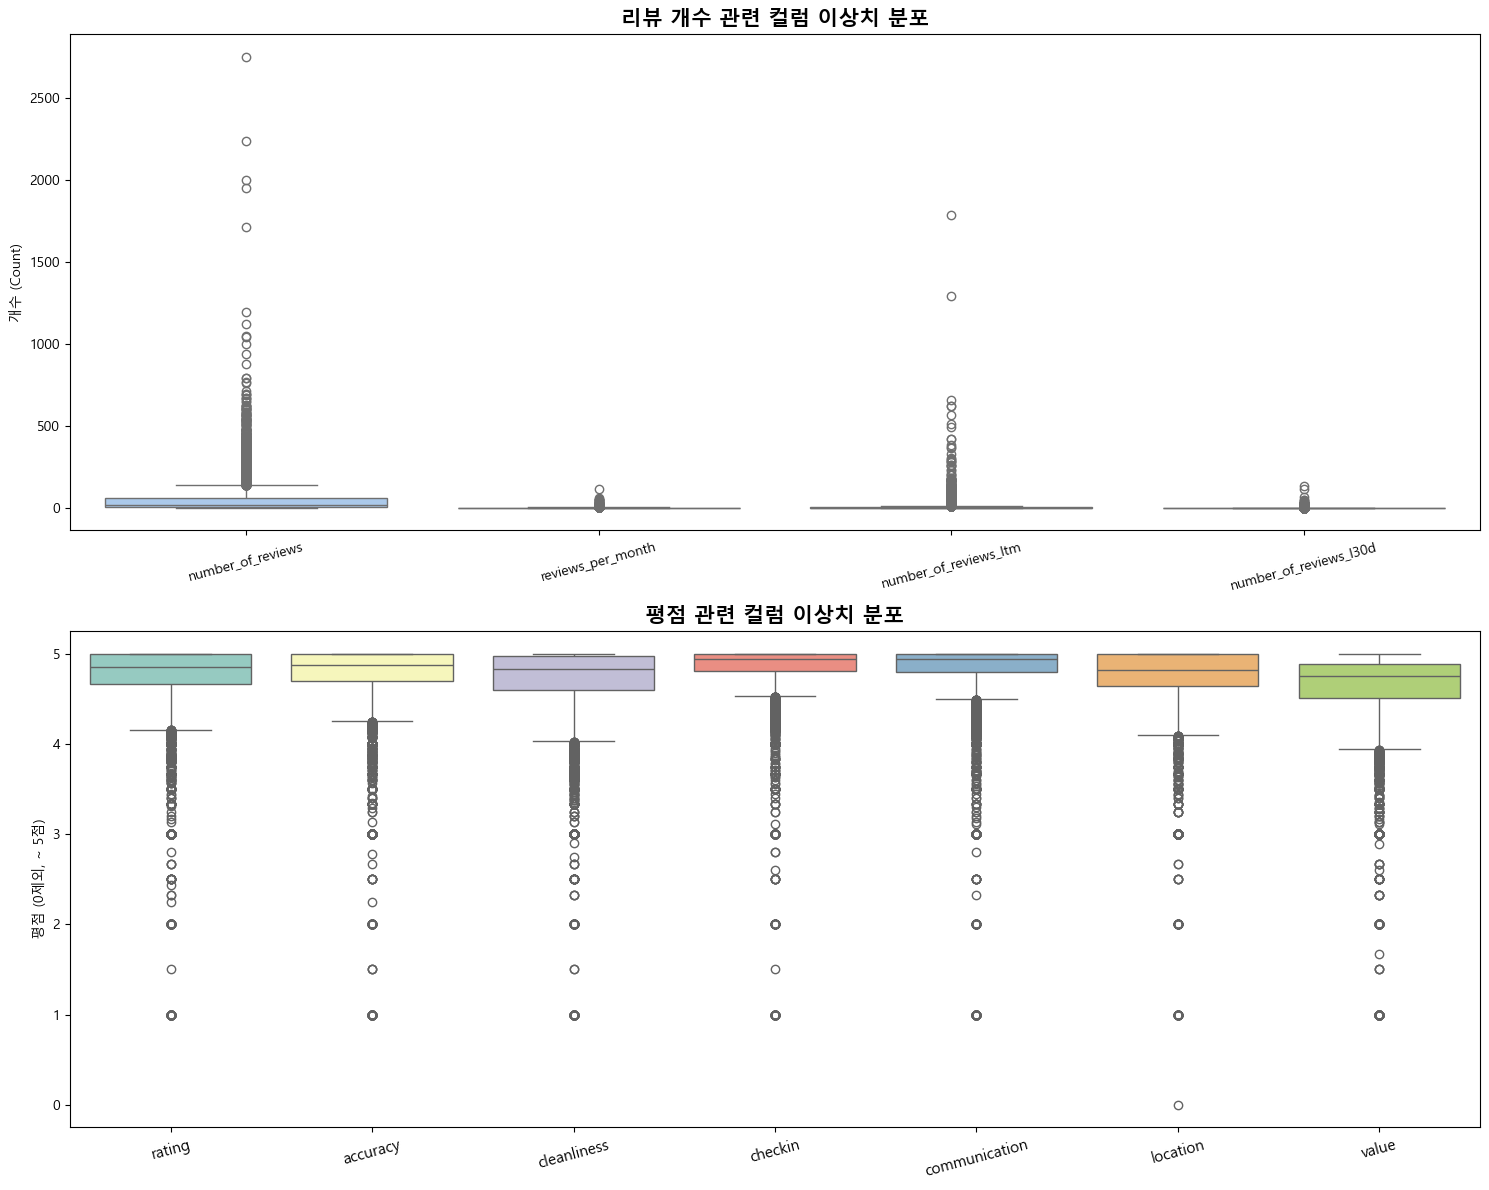

In [10]:
# 시각화
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))

# 리뷰 개수 관련 이상치 (리뷰 없음 제외)
sns.boxplot(data=df_with_reviews[count_cols], ax=axes[0], palette="pastel")
axes[0].set_title("리뷰 개수 관련 컬럼 이상치 분포", fontsize=15, fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylabel("개수 (Count)")

# 평점 관련 이상치 (리뷰 없음 제외)
sns.boxplot(data=df_with_reviews[score_cols], ax=axes[1], palette="Set3")
axes[1].set_title("평점 관련 컬럼 이상치 분포", fontsize=15, fontweight="bold")

clean_labels = [col.replace("review_scores_", "") for col in score_cols]
axes[1].set_xticklabels(clean_labels, rotation=15, fontsize=11)

axes[1].set_ylabel("평점 (0제외, ~ 5점)")

plt.tight_layout()
plt.show()

## 이상치
- 리뷰개수가 극단적으로 많은 숙소들은 '개인 호스트'보다 '기업형'일 확률이 높지 않을까?

In [11]:
# 리뷰 많은 순으로 데이터 정렬해서 패턴 찾아보기
cols = [
    "name",
    "host_name",
    "number_of_reviews",
    "price",
    "review_scores_rating",
    "host_is_superhost",
    "property_type",
    "room_type",
]

df_cleaned[cols].sort_values("number_of_reviews", ascending=False).head()

,name,host_name,number_of_reviews,price,review_scores_rating,host_is_superhost,property_type,room_type
13316,"Safe and Cozy Hostel Room, 1 person, Manhattan",Alfred,2749,58.0,4.70,False,Private room in bed and breakfast,Private room
9458,Individual Cubicle Room in NYC/Mixed Floor,Alex And Zeena,2238,65.0,4.58,False,Private room in hostel,Private room
7870,Untitled at 3 Freeman - Studio Queen,Untitled,1998,159.0,4.88,True,Entire rental unit,Entire home/apt
4986,Amazing Micro Unit W/ communal rooftop and kit...,The Ridge,1951,162.0,4.54,False,Room in boutique hotel,Private room
10703,SoHo View Room (Full-Size Bed) in Hotel Comfort,SoHoBlu,1709,124.0,4.53,False,Entire loft,Entire home/apt


# 다변량 분석 
- 평점 관련 이슈 파악

In [12]:
# 평점이 높은 순으로 정렬해서 패턴 파악해보기
cols = [
    "name",
    "host_name",
    "number_of_reviews",
    "price",
    "review_scores_rating",
    "host_is_superhost",
    "property_type",
    "room_type",
]

df_cleaned[cols].sort_values("review_scores_rating", ascending=False).head()

,name,host_name,number_of_reviews,price,review_scores_rating,host_is_superhost,property_type,room_type
21699,NYC Skyline Penthouse 2Br/2Bath,Andrew,2,942.0,5.0,False,Entire rental unit,Entire home/apt
21697,Upscale Comfort: Stylish 2BR in the Heart of NYC,Krystian,2,344.0,5.0,True,Entire rental unit,Entire home/apt
21674,Spacious 3BR Family Haven in Lower Manhattan,Rouzbeh,2,465.0,5.0,False,Entire rental unit,Entire home/apt
21339,Modern Two Bedroom in NYC!,Frank,4,241.0,5.0,False,Entire rental unit,Entire home/apt
21228,Private Room Home Cinema Queens,Wayne,5,100.0,5.0,False,Private room in home,Private room


### 세부 평점이 전체 평점에 얼마나 영향을 주고 있는지?
- 세부 평점의 영향 정도 피익할 필요성 → 전체 평점과의 상관관계 파악

In [13]:
# 세부 평점 컬럼들
detail_score_cols = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]

# 리뷰가 있는 숙소 중에서, 세부 평점 평균 + 높은 순으로 정렬
detail_score_means = df_with_reviews[detail_score_cols].mean().sort_values(ascending=False)

display(detail_score_means.round(3))

review_scores_checkin          4.831
review_scores_communication    4.813
review_scores_accuracy         4.753
review_scores_location         4.729
review_scores_cleanliness      4.688
review_scores_value            4.613
dtype: float64

##### 리뷰가 있는 숙소의, 세부평점 평균 분석:
- 평균 평점이 가장 높은 것: chekin 과 communication 과 같은 호스트와의 직접적인 상호작용 점수 
-> 관대함 이슈 (사람은 예쁘게 봐줌)
- 평균 평점이 가장 낮은 것: value, cleanlines 가성비와 청결도 -> 깐깐하게 점수준다. (돈, 청결 민감)
- accuracy, location 과 같은 실제 장소적 특징들은 중간대 점수 → 관대 깐깐 반반 이슈

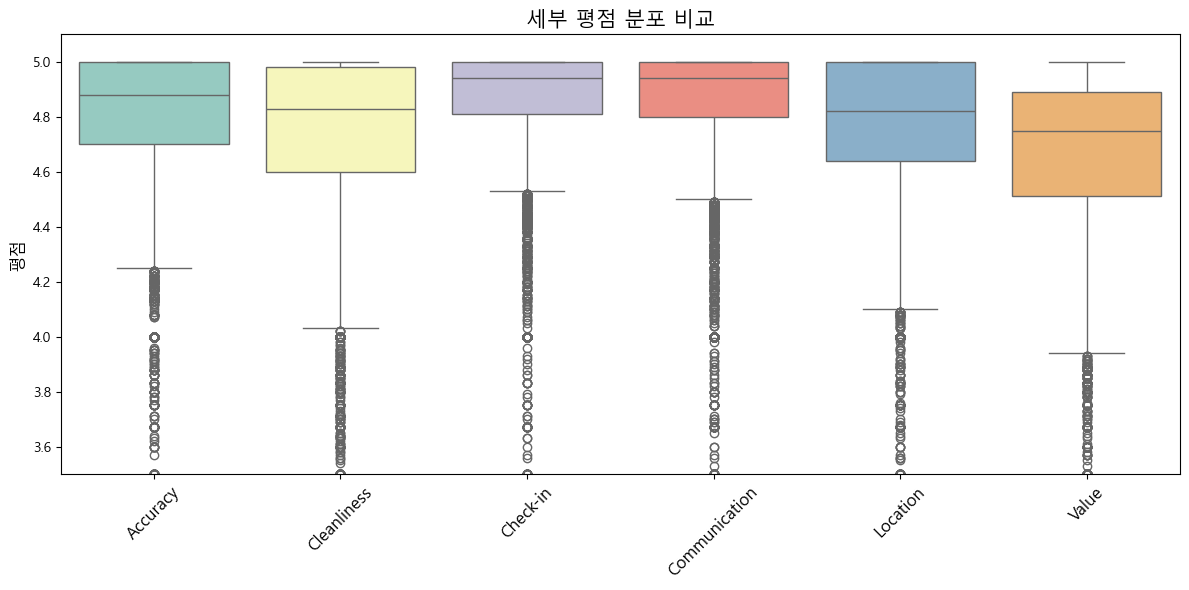

In [ ]:
# Boxplot 시각화
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_with_reviews[detail_score_cols], palette="Set3")
plt.title("세부 평점 분포 비교", fontsize=15)

clean_labels = ["Accuracy", "Cleanliness", "Check-in", "Communication", "Location", "Value"]
plt.xticks(ticks=range(len(detail_score_cols)), labels=clean_labels, rotation=45, fontsize=12)
plt.ylabel("평점", fontsize=12)
plt.ylim(3.5, 5.1)
plt.tight_layout()
plt.show()

# 리뷰/평점 과 다른 컬럼들 상관계수 살펴보기

In [ ]:
# 리뷰,평점이랑 다른 수치형 컬럼들 한번에 상관계수 확인
review_related_cols = [
    "host_id",
    "host_listings_count",
    "host_total_listings_count",
    "host_response_rate",
    "host_acceptance_rate",
    "price",
    "accommodates",
    "bathrooms",
    "estimated_occupancy_l365d",
]

df_cleaned[review_related_cols + ["review_scores_rating", "number_of_reviews"]].corr()[
    ["review_scores_rating", "number_of_reviews"]
].sort_values("review_scores_rating", ascending=False)

,review_scores_rating,number_of_reviews
review_scores_rating,1.000000,0.066157
estimated_occupancy_l365d,0.110858,0.365630
host_response_rate,0.069113,0.062908
number_of_reviews,0.066157,1.000000
price,0.043957,-0.051742
bathrooms,0.012022,-0.054077
accommodates,0.002404,-0.002891
host_acceptance_rate,0.000037,0.132097
host_id,-0.109332,-0.146375
host_listings_count,-0.115952,-0.136580


In [ ]:
# 세부 평점 컬럼들
detail_score_cols = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]

# 영향을 주는 요인들
other_cols = [
    "host_id",
    "host_listings_count",
    "host_total_listings_count",
    "host_response_rate",
    "host_acceptance_rate",
    "price",
    "accommodates",
    "bathrooms",
    "estimated_occupancy_l365d",
    "number_of_reviews",
    "review_scores_rating",
]

corr_matrix = df_cleaned[detail_score_cols + other_cols].corr()
detail_corr_view = corr_matrix.loc[other_cols, detail_score_cols]

detail_corr_view.sort_values(by="review_scores_rating", axis=1, ascending=False)

,review_scores_accuracy,review_scores_value,review_scores_communication,review_scores_cleanliness,review_scores_checkin,review_scores_location
host_id,-0.115556,-0.100978,-0.097601,-0.057282,-0.100309,-0.095641
host_listings_count,-0.094071,-0.170163,-0.157632,-0.065064,-0.096281,-0.029518
host_total_listings_count,-0.110757,-0.174413,-0.158997,-0.070932,-0.106184,-0.035987
host_response_rate,0.056289,0.054140,0.100481,0.069772,0.048293,0.019975
host_acceptance_rate,0.006225,0.005885,0.017948,0.040784,0.004488,-0.027162
price,0.034710,0.012483,0.023769,0.055828,0.022294,0.085849
accommodates,0.003727,-0.004476,0.014918,0.020362,-0.001980,-0.005912
bathrooms,-0.003146,0.015008,-0.002648,0.001537,0.007603,-0.001752
estimated_occupancy_l365d,0.101137,0.103298,0.092192,0.119265,0.083278,0.067171
number_of_reviews,0.085623,0.113258,0.077162,0.088116,0.070137,0.036335


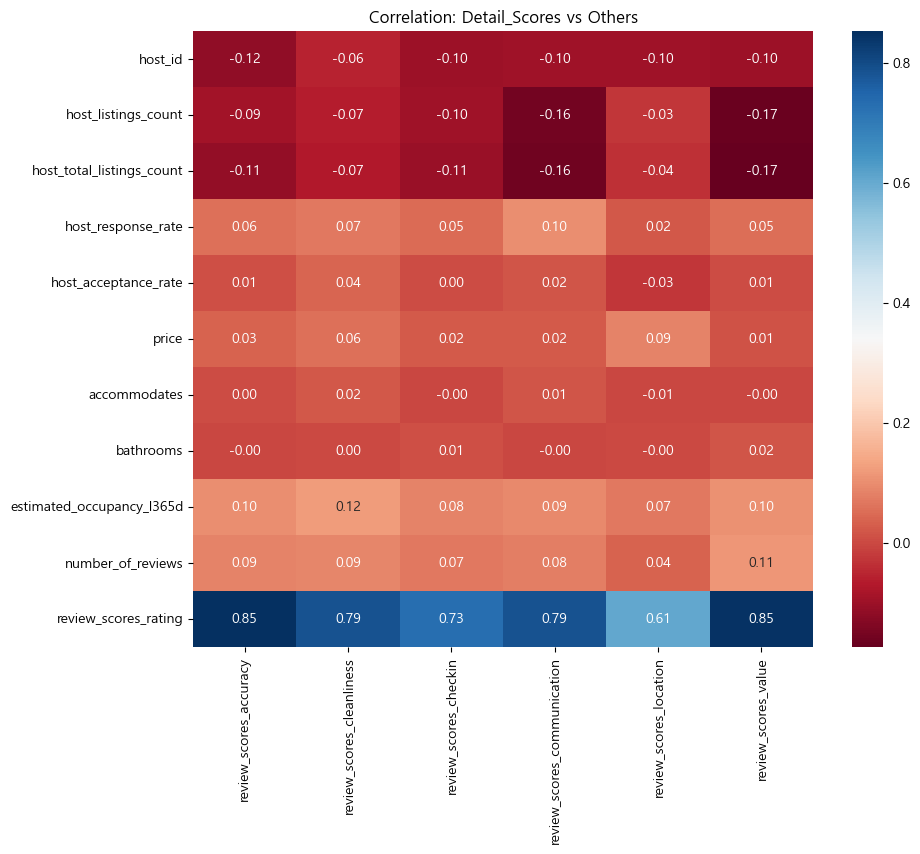

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(detail_corr_view, annot=True, cmap="RdBu", fmt=".2f")
plt.title("Correlation: Detail_Scores vs Others")
plt.show()

In [ ]:
# 결측치 확인 및 처리
# df_cleaned[df_cleaned["host_since"].isna()][["host_since"]]

host_since_mode = df_cleaned["host_since"].mode()[0]

df_cleaned["host_since"] = df_cleaned["host_since"].fillna(host_since_mode)

df_cleaned["host_since"].isna().sum()

np.int64(0)

# 다변량 분석
- host since 활용, 경력 계산 -> 경력과 다른 컬럼들 간의 상관관계 살펴보기

## 최신 스크랩 날짜(2025/03/02) 와 host_since(가입날짜)를 활용해서 호스트 활동 경력 구하기 

<Axes: xlabel='host_since', ylabel='Count'>

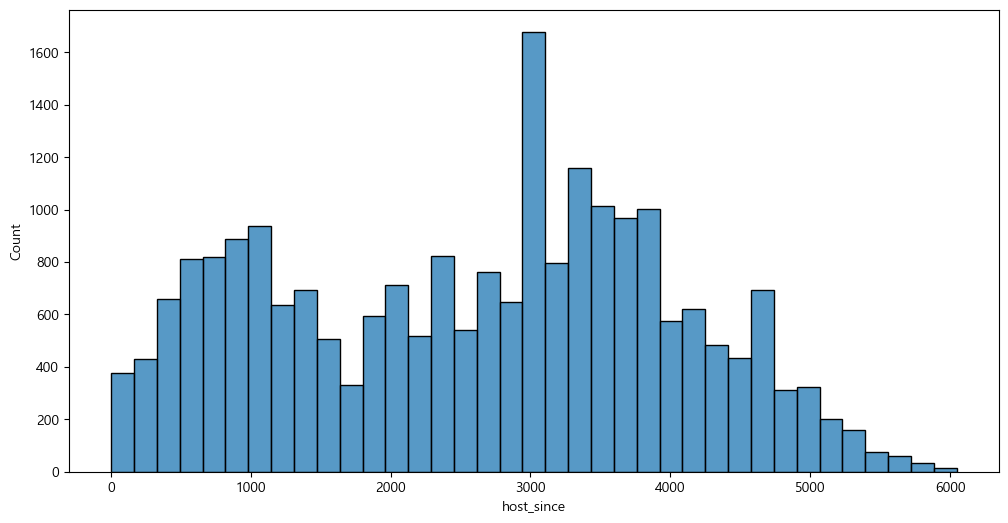

In [63]:
base_date = datetime(2025, 3, 2)
sns.histplot((base_date - pd.to_datetime(df_cleaned["host_since"])).dt.days)

In [64]:
# 기준일 설정 및 날짜 데이터 변환
base_date = datetime(2025, 3, 2)
df_cleaned["host_since"] = pd.to_datetime(df_cleaned["host_since"])

# 호스트 경력(기간) 계산
df_cleaned["host_tenure_days"] = (base_date - df_cleaned["host_since"]).dt.days

# 상관계수 확인
# 호스트 경력과 세부 평점들 간의 상관계수
df_cleaned[detail_score_cols + ["host_tenure_days"]].corr().sort_values("host_tenure_days")

,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_tenure_days
review_scores_cleanliness,0.729393,1.000000,0.621368,0.629899,0.500813,0.717501,0.058803
review_scores_location,0.583130,0.500813,0.562808,0.514133,1.000000,0.572677,0.098522
review_scores_checkin,0.675254,0.621368,1.000000,0.708276,0.562808,0.659384,0.104047
review_scores_communication,0.736111,0.629899,0.708276,1.000000,0.514133,0.717937,0.105726
review_scores_value,0.803240,0.717501,0.659384,0.717937,0.572677,1.000000,0.111877
review_scores_accuracy,1.000000,0.729393,0.675254,0.736111,0.583130,0.803240,0.119957
host_tenure_days,0.119957,0.058803,0.104047,0.105726,0.098522,0.111877,1.000000


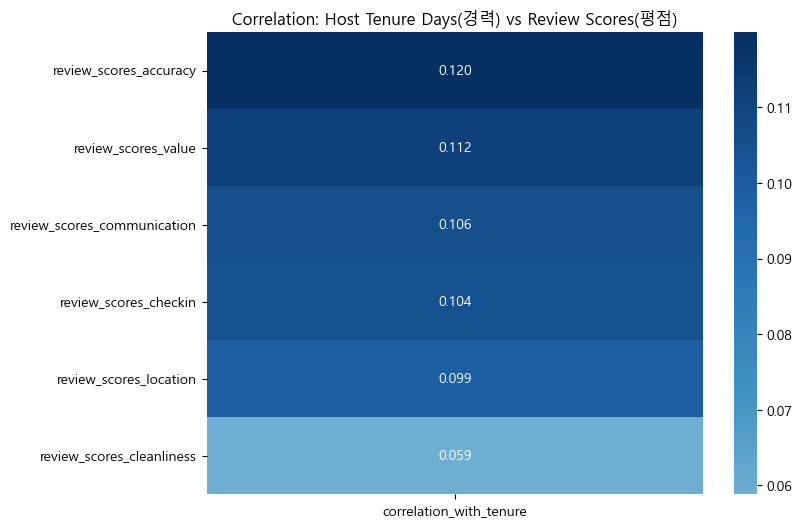

In [65]:
corr_matrix = df_cleaned[detail_score_cols + ["host_tenure_days"]].corr()

# 'host_tenure_days'와 세부 평점 간의 상관계수만 추출
tenure_impact = corr_matrix.loc[detail_score_cols, ["host_tenure_days"]]

# x축
tenure_impact.columns = ["correlation_with_tenure"]

# 히트맵 시각화
plt.figure(figsize=(8, 6))

sns.heatmap(
    tenure_impact.sort_values("correlation_with_tenure", ascending=False), annot=True, cmap="RdBu", center=0, fmt=".3f"
)

plt.title("Correlation: Host Tenure Days(경력) vs Review Scores(평점)")
plt.show()

호스트 경력과 평점의 관계:
- 전체적으로 0.1의 상관계수로, 상관이 뚜렷하게 있다고 보기 어렵지만, 경력이 평점에 어떤 영향을 미치고 있음은 알 수 있다.
- 경력이 쌓인 호스트일 수록 평점 관리 노하우를 터득했을 가능성.
- 경력과 청결도는 관련성이 낮음: 등록된 숙소가 노후화 됨에 따라 청결도를 유지하기 어려울 것으로 예상해 봄.

In [66]:
# 호스트 경력과 가격 간의 상관관계 확인
price_tenure_corr = df_cleaned[["host_tenure_days", "log_price"]].corr().iloc[0, 1]
print(f"호스트 경력과 가격 간의 상관계수: {price_tenure_corr:.4f}")

호스트 경력과 가격 간의 상관계수: 0.0110


## 호스트 시작 연도별 혹은 연차별로 세부 평점 평균 비교 
- "~년에 시작한 호스트들이 유독 ~평점이 높다" 같은 트렌드적 요인

In [67]:
# 가입 연도 컬럼 생성
df_cleaned["host_since_year"] = df_cleaned["host_since"].dt.year

# 연도별 평점 평균 계산
# 분석할 세부 평점 리스트 (detail_score_cols 사용)
yearly_rating_avg = df_cleaned.groupby("host_since_year")[detail_score_cols].mean()
# 결과 확인
print("호스트 가입 연도별 평점 평균:")
display(yearly_rating_avg)

호스트 가입 연도별 평점 평균:


,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
host_since_year,,,,,,
2008,4.846667,4.671667,4.878333,4.678333,4.775833,4.695000
2009,4.839894,4.771596,4.893830,4.887447,4.770000,4.762340
2010,4.847500,4.713456,4.898713,4.892721,4.814632,4.740993
2011,4.829907,4.714333,4.882130,4.896648,4.762333,4.722852
2012,4.800320,4.709591,4.868420,4.868972,4.788365,4.672818
2013,4.853337,4.755827,4.905484,4.903196,4.779748,4.732117
2014,4.801921,4.714119,4.877836,4.875201,4.771145,4.654584
2015,4.775106,4.699646,4.840680,4.794856,4.743272,4.626886
2016,4.778693,4.709243,4.840201,4.818900,4.750725,4.614861


In [68]:
df_cleaned["host_since_year"].value_counts()

host_since_year
2016    2793
2015    2305
2022    2021
2014    1891
2023    1708
2017    1600
2021    1501
2018    1490
2019    1436
2012    1186
2013    1184
2024    1166
2020     867
2011     630
2010     310
2009     107
2025     100
2008      13
Name: count, dtype: int64

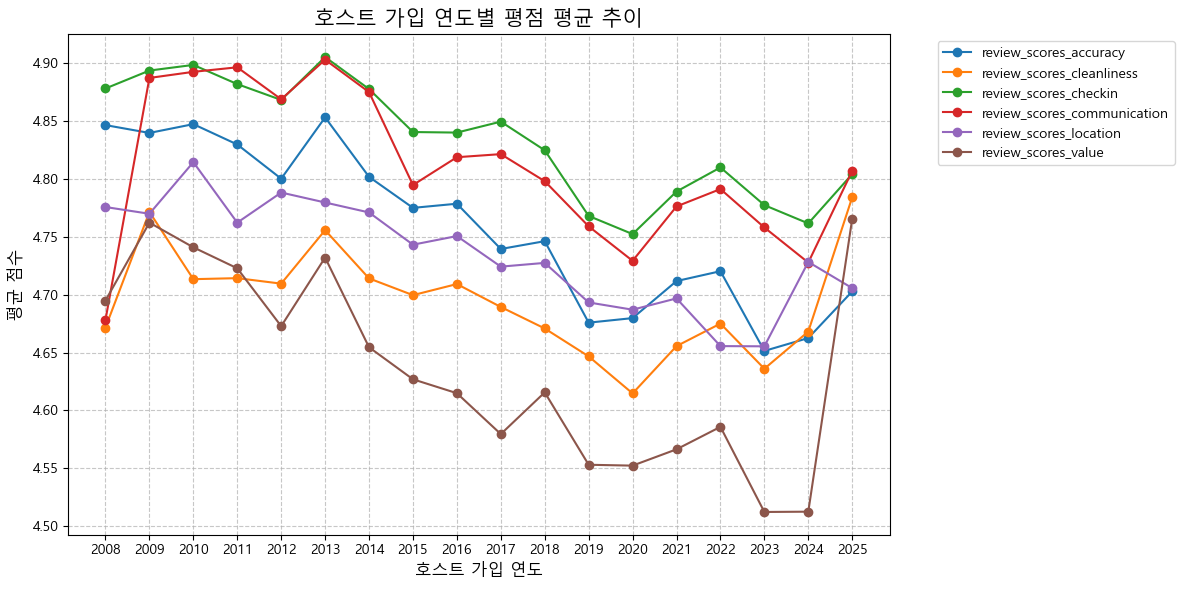

In [69]:
# 시각화
plt.figure(figsize=(12, 6))

# 모든 세부 평점 항목에 대해 선 그래프 그리기
for col in detail_score_cols:
    plt.plot(yearly_rating_avg.index, yearly_rating_avg[col], marker="o", label=col)

plt.title("호스트 가입 연도별 평점 평균 추이", fontsize=15)
plt.xlabel("호스트 가입 연도", fontsize=12)
plt.ylabel("평균 점수", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # 범례를 그래프 바깥으로 이동
plt.grid(True, linestyle="--", alpha=0.7)

# x축을 연도 단위로 표시
plt.xticks(yearly_rating_avg.index)

plt.tight_layout()
plt.show()

In [ ]:
# 연차 구간 나누기
bins = [0, 1, 3, 5, 10, 20]
labels = ["1년 미만", "1-3년", "3-5년", "5-10년", "10년 이상"]

df_cleaned["tenure_group"] = pd.cut(df_cleaned["host_tenure_days"] / 365, bins=bins, labels=labels, right=False)

# 구간별 평점 평균 확인
display(df_cleaned.groupby("tenure_group")[detail_score_cols].mean())

,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
tenure_group,,,,,,
1년 미만,4.661590,4.670135,4.768841,4.724555,4.742264,4.523154
1-3년,4.688372,4.659990,4.790741,4.773996,4.659405,4.554786
3-5년,4.699368,4.637820,4.779562,4.760577,4.688935,4.552374
5-10년,4.746758,4.684965,4.826617,4.798389,4.728713,4.600744
10년 이상,4.820454,4.725624,4.883212,4.881931,4.777803,4.691168


In [ ]:
# 구간별 데이터 개수 확인
print(df_cleaned["tenure_group"].value_counts().sort_index())

tenure_group
1년 미만      987
1-3년      3425
3-5년      2754
5-10년     9452
10년 이상    5690
Name: count, dtype: int64


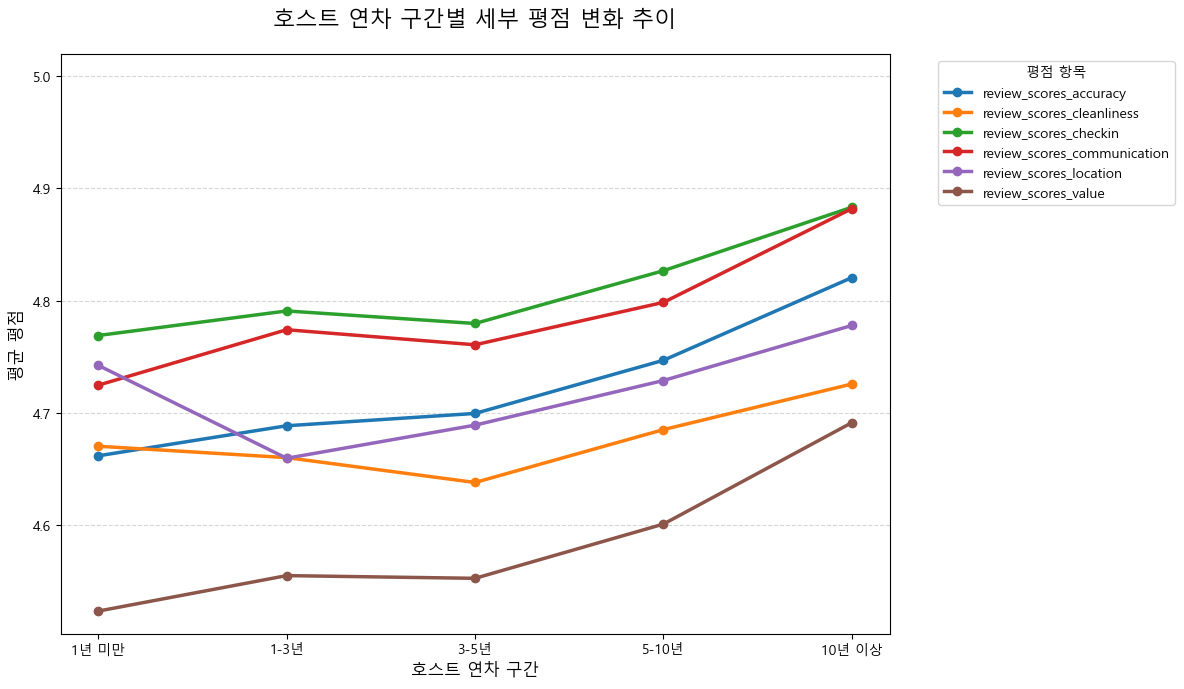

In [ ]:
tenure_group_mean = df_cleaned.groupby("tenure_group")[detail_score_cols].mean()

# 선 그래프 시각화
plt.figure(figsize=(12, 7))

# 각 세부 항목별로 선 그리기
for col in detail_score_cols:
    plt.plot(tenure_group_mean.index, tenure_group_mean[col], marker="o", label=col, linewidth=2.5)

plt.title("호스트 연차 구간별 세부 평점 변화 추이", fontsize=16, pad=20)
plt.xlabel("호스트 연차 구간", fontsize=12)
plt.ylabel("평균 평점", fontsize=12)

plt.ylim(tenure_group_mean.min().min() - 0.02, 5.02)

plt.legend(title="평점 항목", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

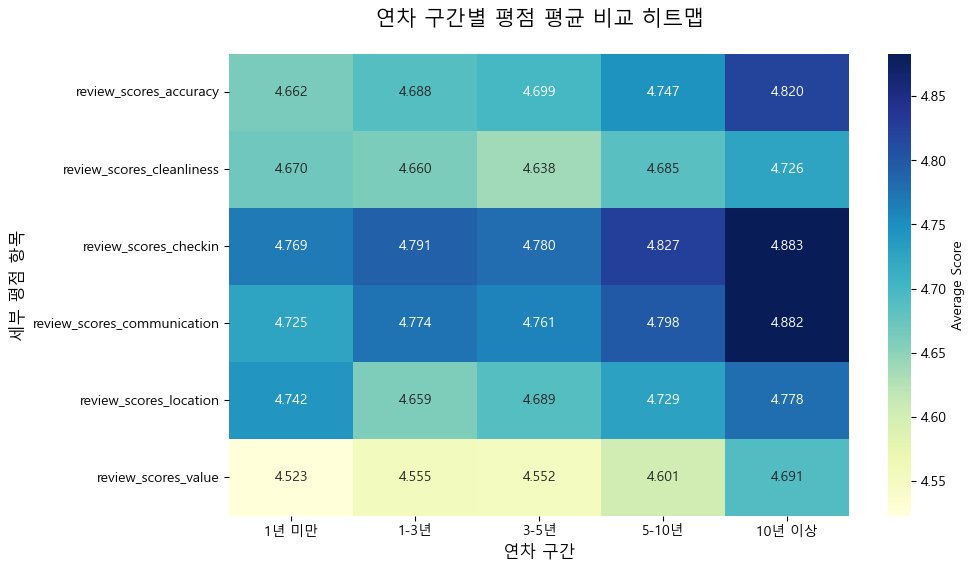

In [ ]:
plt.figure(figsize=(10, 6))

# 행과 열을 바꾸어(T) 항목을 세로로, 연차를 가로로 배치
sns.heatmap(tenure_group_mean.T, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Average Score"})

plt.title("연차 구간별 평점 평균 비교 히트맵", fontsize=15, pad=20)
plt.ylabel("세부 평점 항목", fontsize=12)
plt.xlabel("연차 구간", fontsize=12)
plt.show()

- 리뷰는 있는데 점유율 데이터는 없을 수 있나? -> 리뷰가 0이면 occupancy도 0


# 호스트 유형별 세부 평점 평균
- 한 호스트가 관리하는 숙소 개수(host_listings_count)에 따른 호스트 유형 범주화
- 세부 평점 평균과 비교

In [83]:
# 숙소 개수에 따른 호스트 유형 정의 (1개: 개인, 2~5개: 중소형, 6개 이상: 기업형)
def categorize_host(count):
    if count == 1:
        return "Individual"
    elif count <= 5:
        return "Small-Medium"
    else:
        return "Professional"


df_cleaned["host_business_type"] = df_cleaned["host_listings_count"].apply(categorize_host)

# 호스트 유형별 세부 평점 평균 비교
business_type_performance = df_cleaned.groupby("host_business_type")[detail_score_cols].mean()
display(business_type_performance)

,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
host_business_type,,,,,,
Individual,4.832905,4.758107,4.878825,4.889192,4.765089,4.731251
Professional,4.624143,4.571754,4.755024,4.687065,4.691912,4.418213
Small-Medium,4.796805,4.728720,4.857677,4.858901,4.729730,4.683651
